# Cylindrical Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from analytical.circular_waveguide import CWGAnalytical
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [2]:
from core.em_project import EMProject

project_name = 'CWG_step_split'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

Project 'CWG_step_split' exists. Loading automatically...
FrequencyDomainSolver state loaded from C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\CWG_step_split\fds


C:\Users\Soske\Documents\git_projects\cavsim3d\solvers\frequency_domain.py:1628: UserWarning: Port modes found but no mesh available to load them into. Skipping port mode loading.
  fds._load_internal(path, config)


In [3]:
# 1. Load and prepare geometry
geo = proj.import_geometry(r"./circular_waveguide.step", unit='m', auto_build=False)
geo.add_splitting_plane_at_z(0.075)
geo.add_splitting_plane_at_z(0.15)
# geo.add_splitting_plane_at_z(0.15)
geo.split()

geo.show_split_preview()
geo.build()
geo.name_solids()

geo.generate_mesh(maxh=0.2) # after naming solids, must generate mesh but avoid rebuilding

Invalidating mesh for project 'CWG_step_split'...
Invalidating simulation results for project 'CWG_step_split'...
Solver state reset. Matrices retained.
Full solver reset. All data cleared.
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\CWG_step_split
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\CWG_step_split\fds
Named 3 solids, 4 ports
  External: port1, port4
  Internal: port2, port3
Displayed 3 solids with distinct colors
Displayed 2 splitting plane(s)


Named 3 solids, 4 ports
  External: port1, port4
  Internal: port2, port3


In [4]:
geo.show('mesh')

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [5]:
# 2. Analytical
radius = 150e-3  # Width: 150 mm
L = 300e-3  # Length: 300 mm
analytical = CWGAnalytical(radius=radius, length=L)

fom_config = {
    'nportmodes': 3,
    'order': 3,
    'nsamples': 100,
    'fmin': 1e-3,
    'fmax': 1.5,
    'solver_type': 'direct',
    'rerun': True
}
fom_result = proj.fds.solve(config=fom_config)

INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Compound structure
INFO:: Domains (3): ['cell_1', 'cell_2', 'cell_3']
INFO:: Total Ports (4): ['port1', 'port2', 'port3', 'port4']
INFO:: External Ports (2): ['port1', 'port4']
INFO:: Internal Ports (2): ['port2', 'port3']
INFO:: 
Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (internal)']
  cell_2: ['port2 (internal)', 'port3 (internal)']
  cell_3: ['port3 (internal)', 'port4 (external, output)']

Assembling Matrices...
Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port1: circular (fit error: 0.0000)
	    R=0.150007
	  port2: circular (fit error: 0.0000)
	    R=0.150007
	  port3: circular (fit error: 0.0000)
	    R=0.150007
	  port4: circular (fit error: 0.0000)
	    R=0.150007
	  Precomputing

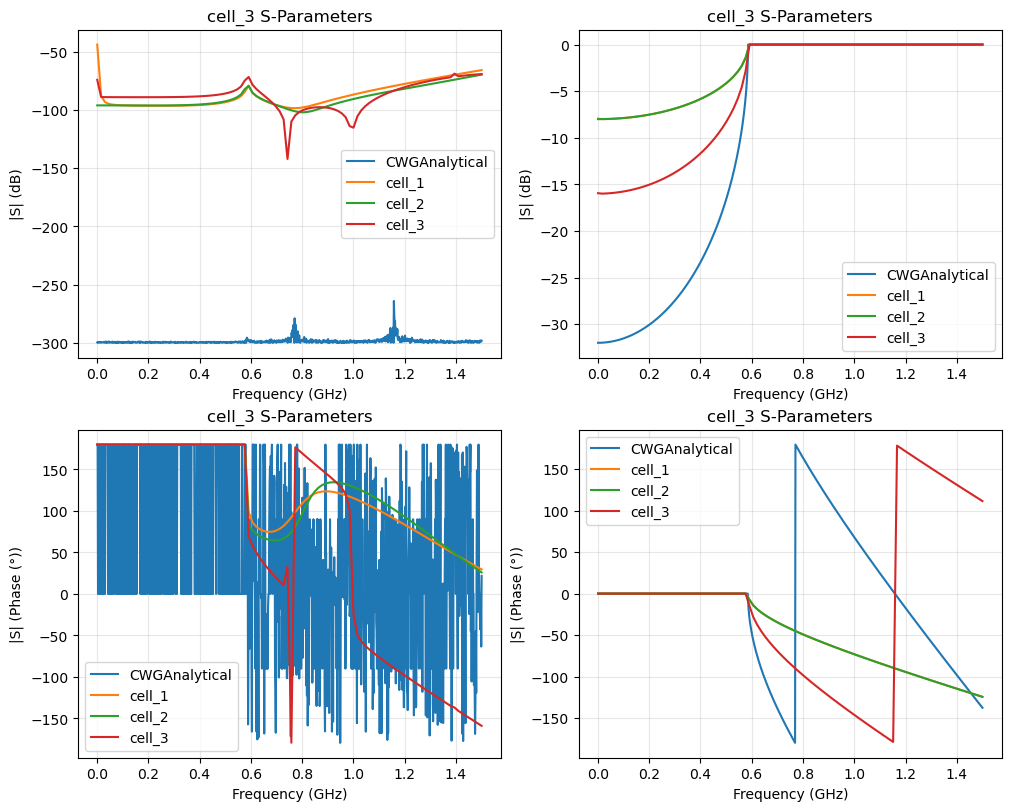

In [6]:
# Get analytic solution for comparison
from analytical.circular_waveguide import CWGAnalytical

radius = 150e-3  # Width: 100 mm
L = 300e-3  # Length: 300 mm
analytical = CWGAnalytical(radius=radius, length=L, freq_range=(fom_config['fmin'], fom_config['fmax']))

# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1])
    proj.fds.foms.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.foms.plot_s(wh, plot_type='phase', ax=axs[idx+3])

In [7]:
proj.fds.plot_port_mode('port2', mode=0, component='abs')


Port Mode: port2 [internal], Mode 0
Cutoff frequency: 0.5856 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [8]:
# Reduce model order
roms = proj.fds.foms.reduce()
concat = proj.fds.foms.roms.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 1.5,
    'solver_type': 'direct', # <- changed to direct method, faster for smaller matrices
    'rerun': True
}
rom_result = concat.solve(config=roms_config) # solve reduced order model on more frequency samples



Model Order Reduction
INFO:: 
Domain: cell_1
INFO:: 
Domain: cell_2
INFO:: 
Domain: cell_3
Total: 9610 → 91 DOFs
Overall compression: 99.1%
INFO:: 
Coupled unified system: 91 -> 85 DOFs
  Solve: 0.260s (1000 frequencies)


Loaded CST S-parameters from: circular_wg
  Frequency range: 0.1000 - 1.5000 GHz (1001 points)
  Ports: 2, Modes per port: 10
  S-parameters loaded: 169


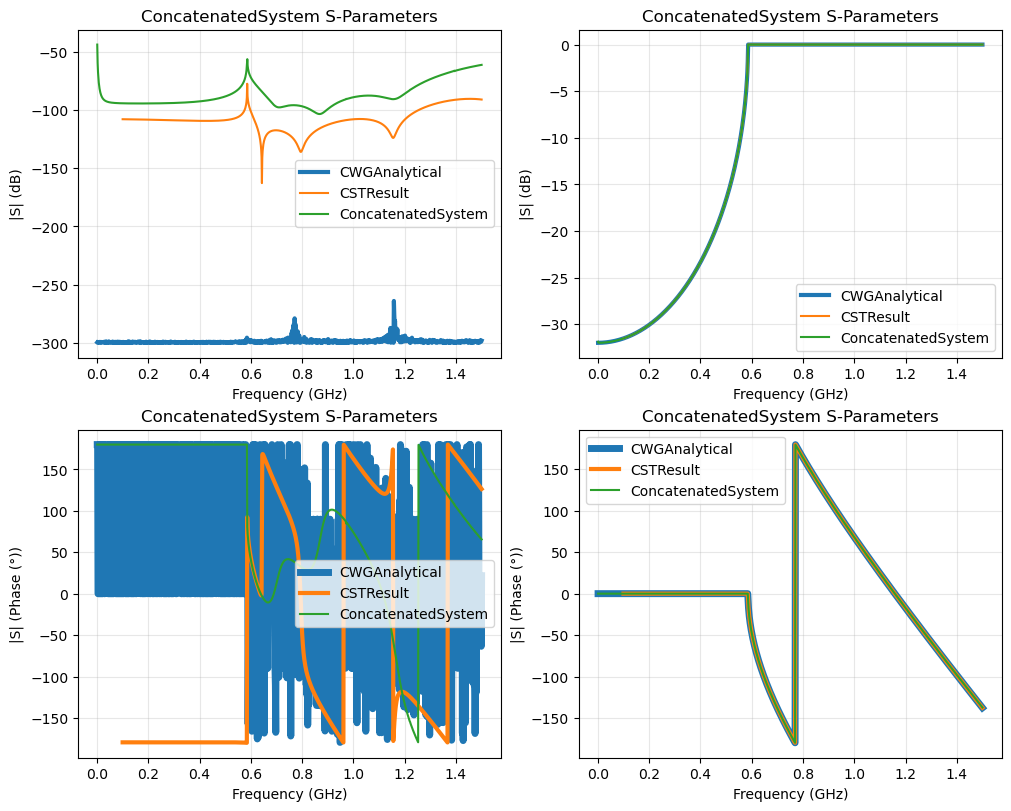

In [9]:
from analytical.cst_result import CSTResult

# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\circular_wg')
# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1], lw=3)
    cstresult.plot_s(wh, ax=axs[idx+1])
    concat.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=5)
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=3)
    concat.plot_s(wh, plot_type='phase', ax=axs[idx+3])


  Note: cell_1 residuals are zero. This is expected when using a direct solver (solver_type='direct').
  Note: cell_2 residuals are zero. This is expected when using a direct solver (solver_type='direct').
  Note: cell_3 residuals are zero. This is expected when using a direct solver (solver_type='direct').


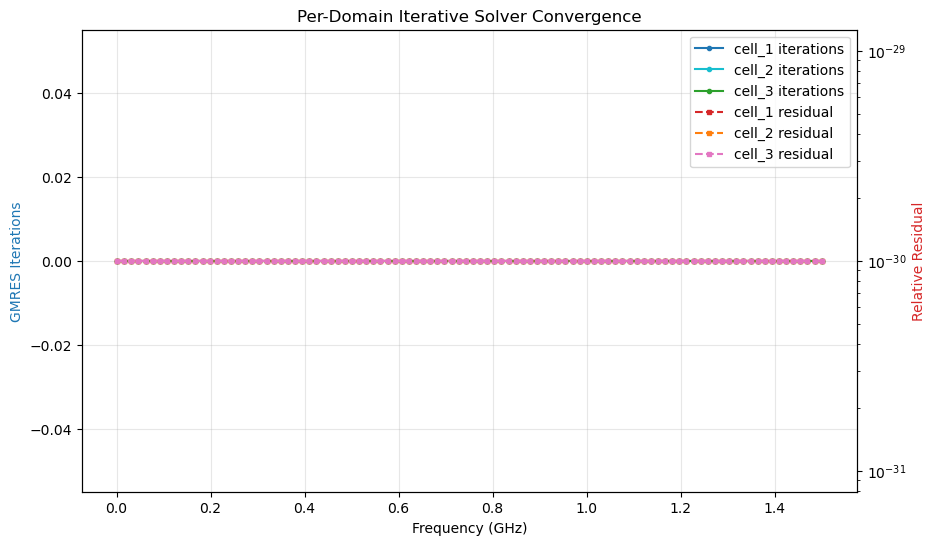

In [10]:
fig, ax = proj.fds.foms.plot_residual()

In [11]:
proj.fds.foms.roms

ROMCollection([cell_1, cell_2, cell_3])